# 06 — Final Evaluation & Cross-Method Comparison
**IDS on CICIDS2018 — Aggregates all results from notebooks 01–05**

Covers:
- Full metric table across all methods (ML baselines, optimization, deep learning, hybrid)
- Operating frontier (FAR vs Attack Recall)
- Best-per-category breakdown
- PR curve comparison (top models)
- Training time vs performance scatter
- CDC compliance checklist
- Concept drift summary from notebook 05

In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import precision_recall_curve, auc

from shared.config import *
from shared.plots import plot_frontier

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 2 — Load all results from previous notebooks
import os

# ── Notebook 02: ML baselines ───────────────────────────────
with open("models/ml/all_results.pkl", "rb") as f:
    ml_results = pickle.load(f)
with open("models/ml/all_probas.pkl", "rb") as f:
    ml_probas = pickle.load(f)

# ── Notebook 03: Optimization ───────────────────────────────
with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)

# ── Notebook 04: Deep learning ──────────────────────────────
with open("models/dl/dl_results.pkl", "rb") as f:
    dl_data = pickle.load(f)

# ── Notebook 05: Hybrid ensemble ────────────────────────────
with open("models/hybrid/hybrid_results.pkl", "rb") as f:
    hybrid_data = pickle.load(f)

# ── Test labels (for PR curves) ─────────────────────────────
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)
y_test = splits["y_test"]

print("All results loaded")
print(f"  ML baselines  : {list(ml_results.keys())}")
print(f"  Opt methods   : {[k for k in opt_data if k.endswith('_m')]}")
print(f"  DL keys       : {list(dl_data.keys())}")
print(f"  Hybrid keys   : {list(hybrid_data.keys())}")

All results loaded
  ML baselines  : ['XGBoost', 'LightGBM']
  Opt methods   : ['optuna_m', 'fi_m', 'uni_m', 'pca_m', 'pso_m', 'smote_m', 'spw_m']
  DL keys       : ['mlp_m', 'proba_mlp_test', 'proba_mlp_val', 'th_mlp', 'train_losses', 'val_losses', 'lr_history', 'best_epoch']
  Hybrid keys   : ['hybrid_m', 'proba_hybrid_test', 'proba_hybrid_val', 'th_hybrid', 'y_pred_hybrid', 'drift_detected', 'window_scores']


In [6]:
import pickle
with open("models/ml/all_results.pkl", "rb") as f:
    ml_results = pickle.load(f)

print("ml_results keys:", list(ml_results.keys()))

ml_results keys: ['XGBoost', 'LightGBM']


In [5]:
# Add this BEFORE building `final` to inspect actual keys
print("ml_results keys:", list(ml_results.keys()))
print("opt_data keys:", list(opt_data.keys()))
print("dl_data keys:", list(dl_data.keys()))
print("hybrid_data keys:", list(hybrid_data.keys()))

ml_results keys: ['XGBoost', 'LightGBM']
opt_data keys: ['optuna_m', 'fi_m', 'uni_m', 'pca_m', 'pso_m', 'smote_m', 'spw_m', 'study', 'best_params', 'top_features', 'pso_features', 'proba_optuna']
dl_data keys: ['mlp_m', 'proba_mlp_test', 'proba_mlp_val', 'th_mlp', 'train_losses', 'val_losses', 'lr_history', 'best_epoch']
hybrid_data keys: ['hybrid_m', 'proba_hybrid_test', 'proba_hybrid_val', 'th_hybrid', 'y_pred_hybrid', 'drift_detected', 'window_scores']


In [14]:
import pickle
from shared.config import *
from shared.metrics import ids_evaluate

# Load test data
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_test  = splits["X_test"]
y_test  = splits["y_test"]

# Load all individual models
model_files = {
    "Decision Tree": "models/ml/decision_tree.pkl",
    "Random Forest": "models/ml/random_forest.pkl",
    "KNN"          : "models/ml/knn.pkl",
    "Naive Bayes"  : "models/ml/naive_bayes.pkl",
    "SVM"          : "models/ml/svm.pkl",
    "XGBoost"      : "models/ml/xgboost.pkl",
    "LightGBM"     : "models/ml/lightgbm.pkl",
}

ml_results = {}
for name, path in model_files.items():
    with open(path, "rb") as f:
        clf = pickle.load(f)
    proba  = clf.predict_proba(X_test.values)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    m      = ids_evaluate(name, y_test.values, proba, y_pred, 0.5)
    m["Train Time (s)"] = "N/A"
    m["Threshold"]      = 0.5
    ml_results[name]    = m
    print(f"✓ {name}")

# Overwrite the broken all_results.pkl
with open("models/ml/all_results.pkl", "wb") as f:
    pickle.dump(ml_results, f)

print("\nml_results keys:", list(ml_results.keys()))

✓ Decision Tree
✓ Random Forest
✓ KNN
✓ Naive Bayes
✓ SVM
✓ XGBoost
✓ LightGBM

ml_results keys: ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM', 'XGBoost', 'LightGBM']


In [15]:
final = {
    "Decision Tree"    : ml_results["Decision Tree"],
    "Random Forest"    : ml_results["Random Forest"],
    "KNN"              : ml_results["KNN"],
    "Naive Bayes"      : ml_results["Naive Bayes"],
    "SVM"              : ml_results["SVM"],
    "XGBoost (base)"   : ml_results["XGBoost"],
    "LightGBM"         : ml_results["LightGBM"],
    "XGBoost+Optuna"   : opt_data["optuna_m"],
    "Feat. Importance" : opt_data["fi_m"],
    "Univariate (KB)"  : opt_data["uni_m"],
    "PCA"              : opt_data["pca_m"],
    "PSO"              : opt_data["pso_m"],
    "SMOTE"            : opt_data["smote_m"],
    "scale_pos_weight" : opt_data["spw_m"],
    "ResNetMLP"        : dl_data["mlp_m"],
    "Hybrid (ML+DL)"   : hybrid_data["hybrid_m"],
}

In [13]:
import pickle

with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

print(type(splits))
print(splits.keys() if isinstance(splits, dict) else dir(splits))

<class 'dict'>
dict_keys(['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'])


In [12]:
import os

# Check current working directory
print("CWD:", os.getcwd())

# Search more broadly
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".pkl") and any(k in f for k in ["test", "train", "val", "split", "data"]):
            print(os.path.join(root, f))

CWD: /home/rafeh/pcd
./models/splits.pkl
./models/ml/trained_models.pkl


In [16]:
# Cell 4 — Full IEEE-style metric table

COLS = [
    "Balanced Acc", "F1 Macro", "MCC",
    "Attack Recall", "Benign Recall",
    "Attack Precision", "Benign Precision",
    "FAR", "FNR", "ROC-AUC", "PR-AUC"
]

rows = []
for name, m in final.items():
    row = {"Method": name}
    for c in COLS:
        val = m.get(c, "N/A")
        row[c] = f"{val:.4f}" if isinstance(val, float) else str(val)
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values(
    "Balanced Acc", ascending=False
).reset_index(drop=True)

print("FINAL COMPARISON — ALL METHODS (sorted by Balanced Accuracy)")
print("=" * 130)
print(summary_df.to_string(index=False))

os.makedirs("outputs/reports", exist_ok=True)
summary_df.to_csv("outputs/reports/06_final_comparison.csv", index=False)
print("\nSaved → outputs/reports/06_final_comparison.csv")

FINAL COMPARISON — ALL METHODS (sorted by Balanced Accuracy)
          Method Balanced Acc F1 Macro    MCC Attack Recall Benign Recall Attack Precision Benign Precision    FAR    FNR ROC-AUC PR-AUC
  XGBoost (base)       0.9760   0.9779 0.9557        0.9584        0.9935           0.9680           0.9915 0.0065 0.0416  0.9919 0.9832
scale_pos_weight       0.9760   0.9776 0.9553        0.9586        0.9933           0.9670           0.9916 0.0067 0.0414  0.9927 0.9842
  Hybrid (ML+DL)       0.9760   0.9770 0.9540        0.9593        0.9928           0.9643           0.9917 0.0072 0.0407  0.9924 0.9838
       ResNetMLP       0.9747   0.9782 0.9565        0.9549        0.9945           0.9727           0.9908 0.0055 0.0451  0.9882 0.9784
           SMOTE       0.9733   0.9758 0.9517        0.9533        0.9932           0.9663           0.9905 0.0068 0.0467  0.9875 0.9773
  XGBoost+Optuna       0.9719   0.9821 0.9648        0.9442        0.9995           0.9976           0.9887 0.0005 0.

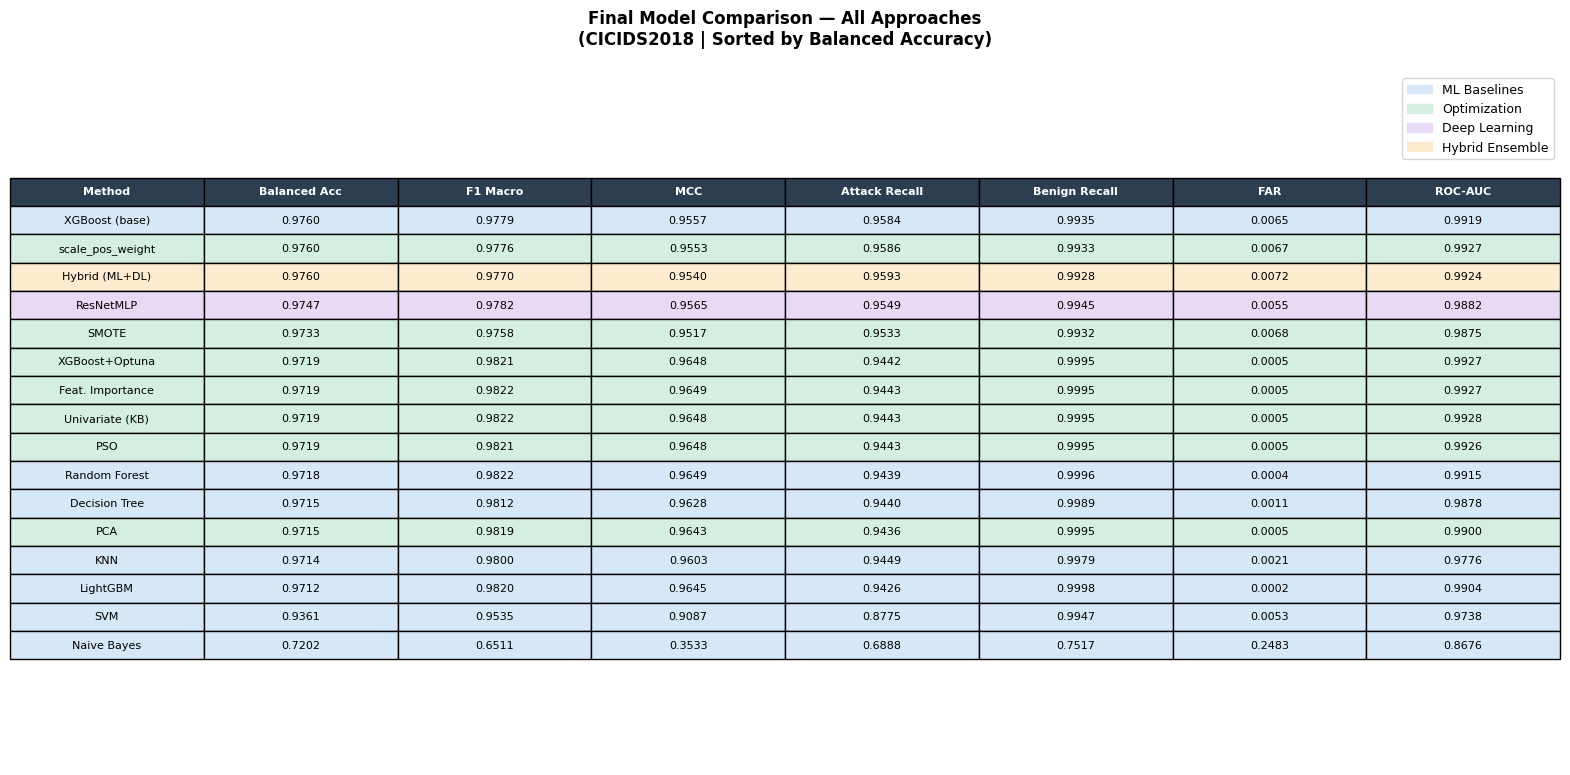

Saved → outputs/graphs/06_final_table.png


In [17]:
# Cell 5 — Summary table figure (rendered as matplotlib table)

KEY_COLS = ["Method", "Balanced Acc", "F1 Macro",
            "MCC", "Attack Recall", "Benign Recall",
            "FAR", "ROC-AUC"]

table_data = summary_df[KEY_COLS].values.tolist()

# Colour rows by category
cat_colors = {
    "Decision Tree"    : "#D6E8F7",
    "Random Forest"    : "#D6E8F7",
    "KNN"              : "#D6E8F7",
    "Naive Bayes"      : "#D6E8F7",
    "SVM"              : "#D6E8F7",
    "XGBoost (base)"   : "#D6E8F7",
    "LightGBM"         : "#D6E8F7",
    "XGBoost+Optuna"   : "#D4EEE2",
    "Feat. Importance" : "#D4EEE2",
    "Univariate (KB)"  : "#D4EEE2",
    "PCA"              : "#D4EEE2",
    "PSO"              : "#D4EEE2",
    "SMOTE"            : "#D4EEE2",
    "scale_pos_weight" : "#D4EEE2",
    "ResNetMLP"        : "#E8D9F5",
    "Hybrid (ML+DL)"   : "#FDEBD0",
}

cell_colors = []
for row in summary_df[KEY_COLS].values:
    method = row[0]
    c = cat_colors.get(method, "#FFFFFF")
    cell_colors.append([c] * len(KEY_COLS))

fig, ax = plt.subplots(figsize=(20, 9))
ax.axis("off")

tbl = ax.table(
    cellText=table_data,
    colLabels=KEY_COLS,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.7)

# Bold header
for j in range(len(KEY_COLS)):
    tbl[(0, j)].set_facecolor("#2C3E50")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

# Legend patches
legend_patches = [
    mpatches.Patch(color="#D6E8F7", label="ML Baselines"),
    mpatches.Patch(color="#D4EEE2", label="Optimization"),
    mpatches.Patch(color="#E8D9F5", label="Deep Learning"),
    mpatches.Patch(color="#FDEBD0", label="Hybrid Ensemble"),
]
ax.legend(handles=legend_patches, loc="upper right",
          bbox_to_anchor=(1.0, 1.0), fontsize=9)

ax.set_title(
    "Final Model Comparison — All Approaches\n"
    "(CICIDS2018 | Sorted by Balanced Accuracy)",
    fontweight="bold", pad=20, fontsize=12
)

os.makedirs("outputs/graphs", exist_ok=True)
plt.savefig("outputs/graphs/06_final_table.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/graphs/06_final_table.png")

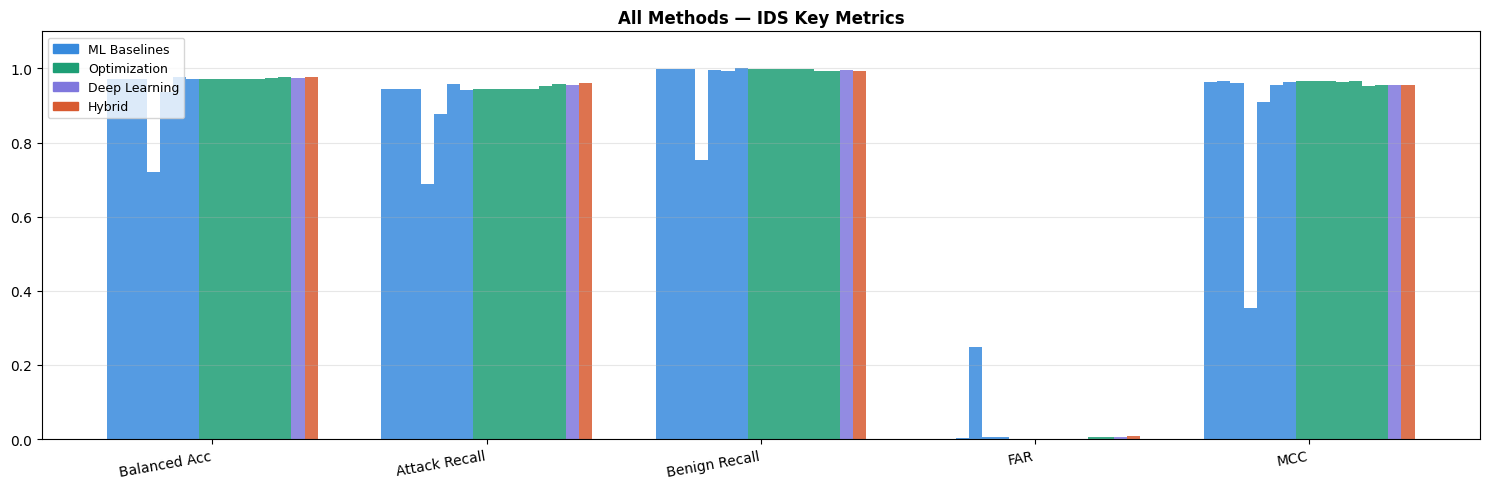

Saved → outputs/graphs/06_grouped_bar.png


In [18]:
# Cell 6 — Grouped metric bar chart (key IDS metrics)

KEY_METRICS = ["Balanced Acc", "Attack Recall", "Benign Recall", "FAR", "MCC"]

# Define method groups + palette
groups = {
    "ML Baselines" : ["Decision Tree", "Random Forest", "KNN",
                       "Naive Bayes", "SVM", "XGBoost (base)", "LightGBM"],
    "Optimization" : ["XGBoost+Optuna", "Feat. Importance", "Univariate (KB)",
                       "PCA", "PSO", "SMOTE", "scale_pos_weight"],
    "Deep Learning": ["ResNetMLP"],
    "Hybrid"       : ["Hybrid (ML+DL)"],
}
group_colors = ["#378ADD", "#1D9E75", "#7F77DD", "#D85A30"]

# Flatten all methods in order
all_methods  = [m for g in groups.values() for m in g if m in final]
method_colors = []
for m in all_methods:
    for g, members, c in zip(groups.keys(), groups.values(), group_colors):
        if m in members:
            method_colors.append(c)
            break

x = np.arange(len(KEY_METRICS))
w = 0.048
n = len(all_methods)

fig, ax = plt.subplots(figsize=(15, 5))

for i, (method, color) in enumerate(zip(all_methods, method_colors)):
    m      = final[method]
    vals   = [float(m.get(k, 0)) for k in KEY_METRICS]
    offset = (i - n / 2 + 0.5) * w
    ax.bar(x + offset, vals, w, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(KEY_METRICS, rotation=10, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("All Methods — IDS Key Metrics", fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

legend_patches = [
    mpatches.Patch(color=c, label=g)
    for g, c in zip(groups.keys(), group_colors)
]
ax.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig("outputs/graphs/06_grouped_bar.png", dpi=150)
plt.show()
print("Saved → outputs/graphs/06_grouped_bar.png")

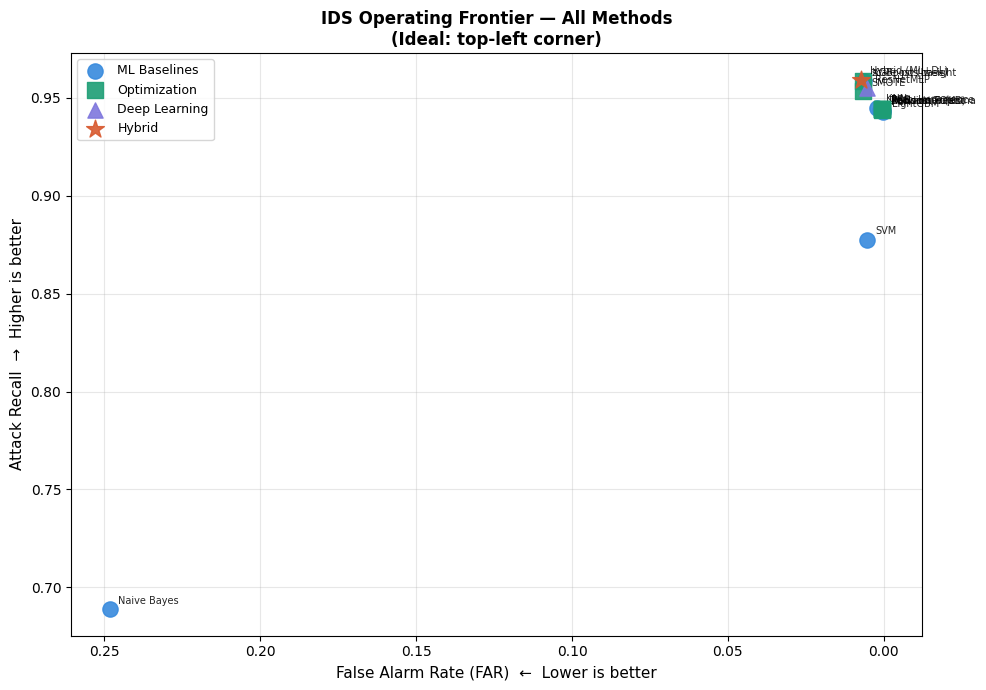

Saved → outputs/graphs/06_frontier_all.png


In [19]:
# Cell 7 — IDS Operating Frontier (FAR vs Attack Recall)
# Upper-left corner = ideal (low FAR, high Attack Recall)

groups = {
    "ML Baselines" : ["Decision Tree", "Random Forest", "KNN",
                       "Naive Bayes", "SVM", "XGBoost (base)", "LightGBM"],
    "Optimization" : ["XGBoost+Optuna", "Feat. Importance", "Univariate (KB)",
                       "PCA", "PSO", "SMOTE", "scale_pos_weight"],
    "Deep Learning": ["ResNetMLP"],
    "Hybrid"       : ["Hybrid (ML+DL)"],
}
group_colors  = ["#378ADD", "#1D9E75", "#7F77DD", "#D85A30"]
group_markers = ["o",        "s",        "^",        "*"]

fig, ax = plt.subplots(figsize=(10, 7))

plotted_groups = set()
for (group, members), color, marker in zip(
        groups.items(), group_colors, group_markers):
    for name in members:
        if name not in final:
            continue
        m = final[name]
        label = group if group not in plotted_groups else None
        ax.scatter(
            m["FAR"], m["Attack Recall"],
            s=180 if marker == "*" else 120,
            color=color, marker=marker, zorder=3,
            label=label, alpha=0.9
        )
        ax.annotate(
            name,
            (m["FAR"], m["Attack Recall"]),
            textcoords="offset points",
            xytext=(6, 4), fontsize=7, alpha=0.85
        )
        plotted_groups.add(group)

ax.set_xlabel("False Alarm Rate (FAR)  ←  Lower is better",
              fontsize=11)
ax.set_ylabel("Attack Recall  →  Higher is better",
              fontsize=11)
ax.set_title("IDS Operating Frontier — All Methods\n"
             "(Ideal: top-left corner)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # low FAR on the right makes the frontier intuitive

plt.tight_layout()
plt.savefig("outputs/graphs/06_frontier_all.png", dpi=150)
plt.show()
print("Saved → outputs/graphs/06_frontier_all.png")

  Skipping Random Forest — no proba found


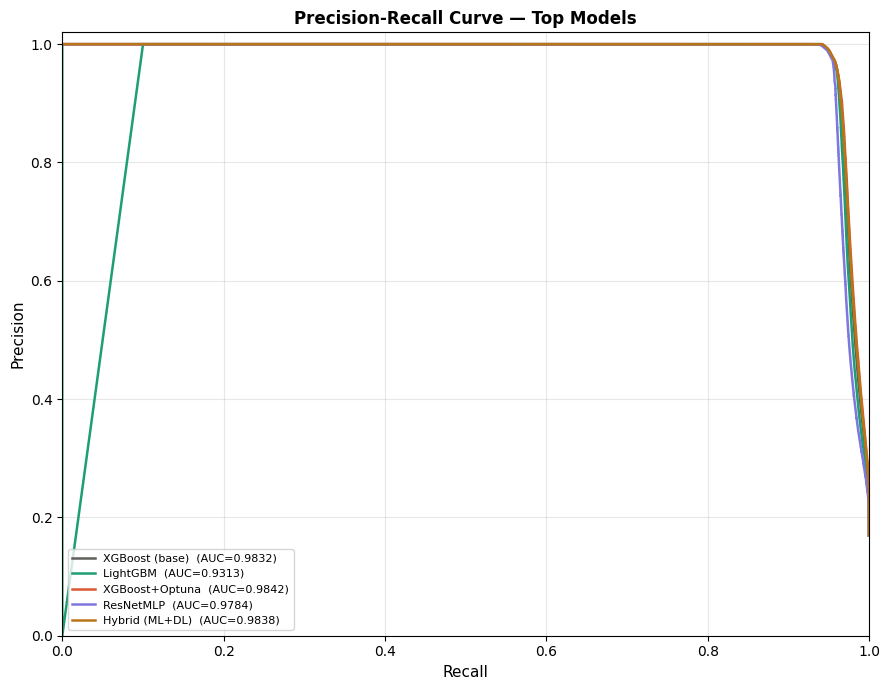

Saved → outputs/graphs/06_pr_curves.png


In [20]:
# Cell 8 — Precision-Recall curves for top models
# Uses stored test probabilities from each notebook

y_test_arr = y_test.values

# Collect (name, proba) for key models
pr_models = {
    "XGBoost (base)"  : ml_probas.get("XGBoost"),
    "Random Forest"   : ml_probas.get("Random Forest"),
    "LightGBM"        : ml_probas.get("LightGBM"),
    "XGBoost+Optuna"  : opt_data["proba_optuna"],
    "ResNetMLP"       : dl_data["proba_mlp_test"],
    "Hybrid (ML+DL)"  : hybrid_data["proba_hybrid_test"],
}

palette = ["#5F5E5A", "#378ADD", "#1D9E75",
           "#D85A30", "#7F77DD", "#BA7517"]

fig, ax = plt.subplots(figsize=(9, 7))

for (name, proba), color in zip(pr_models.items(), palette):
    if proba is None:
        print(f"  Skipping {name} — no proba found")
        continue
    prec, rec, _ = precision_recall_curve(y_test_arr, proba)
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, color=color, linewidth=1.8,
            label=f"{name}  (AUC={pr_auc:.4f})")

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve — Top Models",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("outputs/graphs/06_pr_curves.png", dpi=150)
plt.show()
print("Saved → outputs/graphs/06_pr_curves.png")

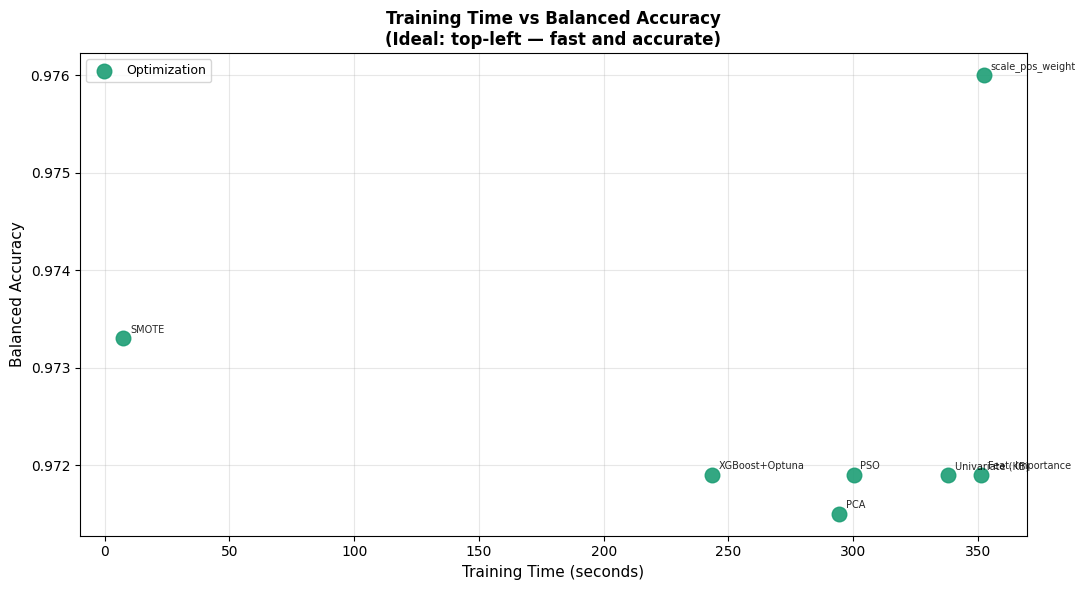

Saved → outputs/graphs/06_time_vs_acc.png


In [21]:
# Cell 9 — Training time vs Balanced Accuracy scatter
# Helps identify the efficiency-vs-performance sweet spot

group_colors = {
    "ML Baselines" : "#378ADD",
    "Optimization" : "#1D9E75",
    "Deep Learning": "#7F77DD",
    "Hybrid"       : "#D85A30",
}
method_group = {
    **{m: "ML Baselines"  for m in ["Decision Tree","Random Forest","KNN",
                                       "Naive Bayes","SVM","XGBoost (base)","LightGBM"]},
    **{m: "Optimization"  for m in ["XGBoost+Optuna","Feat. Importance","Univariate (KB)",
                                       "PCA","PSO","SMOTE","scale_pos_weight"]},
    "ResNetMLP"    : "Deep Learning",
    "Hybrid (ML+DL)": "Hybrid",
}

fig, ax = plt.subplots(figsize=(11, 6))

plotted = set()
for name, m in final.items():
    t = m.get("Train Time (s)", None)
    if t is None or not isinstance(t, (int, float)):
        continue
    bacc  = float(m.get("Balanced Acc", 0))
    group = method_group.get(name, "ML Baselines")
    color = group_colors[group]
    label = group if group not in plotted else None
    ax.scatter(t, bacc, s=110, color=color, alpha=0.9,
               label=label, zorder=3)
    ax.annotate(name, (t, bacc), textcoords="offset points",
                xytext=(5, 4), fontsize=7, alpha=0.85)
    plotted.add(group)

ax.set_xlabel("Training Time (seconds)", fontsize=11)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_title("Training Time vs Balanced Accuracy\n"
             "(Ideal: top-left — fast and accurate)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/graphs/06_time_vs_acc.png", dpi=150)
plt.show()
print("Saved → outputs/graphs/06_time_vs_acc.png")

In [22]:
# Cell 10 — Best model per category

categories = {
    "ML Baselines" : ["Decision Tree", "Random Forest", "KNN",
                       "Naive Bayes", "SVM", "XGBoost (base)", "LightGBM"],
    "Optimization" : ["XGBoost+Optuna", "Feat. Importance", "Univariate (KB)",
                       "PCA", "PSO", "SMOTE", "scale_pos_weight"],
    "Deep Learning": ["ResNetMLP"],
    "Hybrid"       : ["Hybrid (ML+DL)"],
}

print("BEST MODEL PER CATEGORY")
print("=" * 70)

best_per_cat = {}
for cat, members in categories.items():
    available = [m for m in members if m in final]
    if not available:
        print(f"  {cat}: no results found")
        continue
    best_name = max(available,
                    key=lambda x: float(final[x].get("Balanced Acc", 0)))
    best_m    = final[best_name]
    best_per_cat[cat] = (best_name, best_m)

    print(f"\n  [{cat}]")
    print(f"    Best model      : {best_name}")
    print(f"    Balanced Acc    : {best_m.get('Balanced Acc', 'N/A')}")
    print(f"    Attack Recall   : {best_m.get('Attack Recall', 'N/A')}")
    print(f"    Benign Recall   : {best_m.get('Benign Recall', 'N/A')}")
    print(f"    FAR             : {best_m.get('FAR', 'N/A')}")
    print(f"    FNR             : {best_m.get('FNR', 'N/A')}")
    print(f"    F1 Macro        : {best_m.get('F1 Macro', 'N/A')}")
    print(f"    MCC             : {best_m.get('MCC', 'N/A')}")
    print(f"    ROC-AUC         : {best_m.get('ROC-AUC', 'N/A')}")
    print(f"    PR-AUC          : {best_m.get('PR-AUC', 'N/A')}")

BEST MODEL PER CATEGORY

  [ML Baselines]
    Best model      : XGBoost (base)
    Balanced Acc    : 0.976
    Attack Recall   : 0.9584
    Benign Recall   : 0.9935
    FAR             : 0.0065
    FNR             : 0.0416
    F1 Macro        : 0.9779
    MCC             : 0.9557
    ROC-AUC         : 0.9919
    PR-AUC          : 0.9832

  [Optimization]
    Best model      : scale_pos_weight
    Balanced Acc    : 0.976
    Attack Recall   : 0.9586
    Benign Recall   : 0.9933
    FAR             : 0.0067
    FNR             : 0.0414
    F1 Macro        : 0.9776
    MCC             : 0.9553
    ROC-AUC         : 0.9927
    PR-AUC          : 0.9842

  [Deep Learning]
    Best model      : ResNetMLP
    Balanced Acc    : 0.9747
    Attack Recall   : 0.9549
    Benign Recall   : 0.9945
    FAR             : 0.0055
    FNR             : 0.0451
    F1 Macro        : 0.9782
    MCC             : 0.9565
    ROC-AUC         : 0.9882
    PR-AUC          : 0.9784

  [Hybrid]
    Best model      

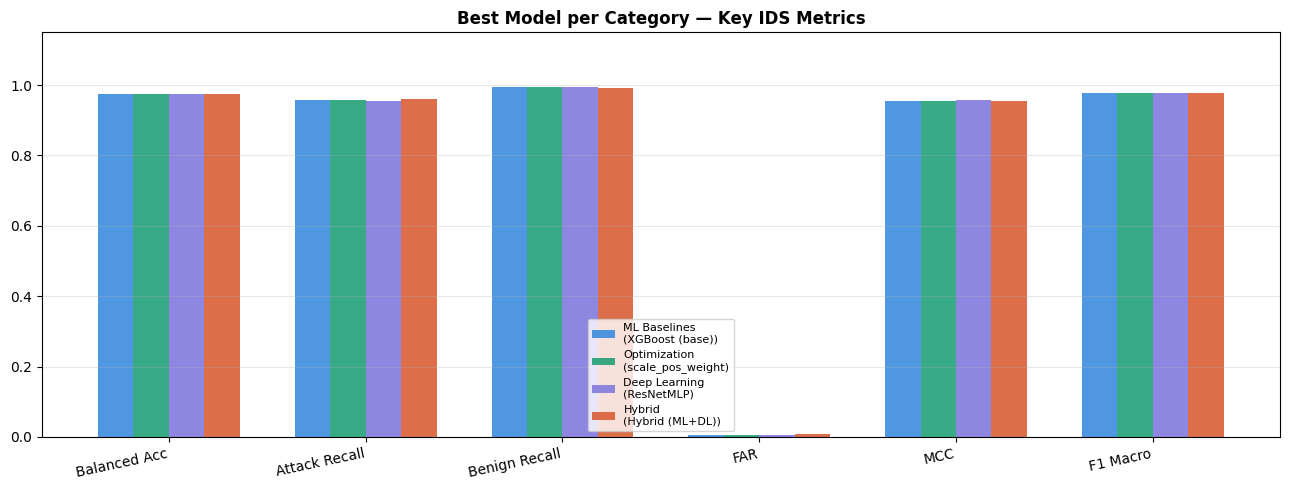

Saved → outputs/graphs/06_best_per_cat.png


In [23]:
# Cell 11 — Best-per-category comparison bar chart

KEY = ["Balanced Acc", "Attack Recall",
       "Benign Recall", "FAR", "MCC", "F1 Macro"]

cat_names  = list(best_per_cat.keys())
cat_palette = ["#378ADD", "#1D9E75", "#7F77DD", "#D85A30"]

x  = np.arange(len(KEY))
w  = 0.18
n  = len(cat_names)

fig, ax = plt.subplots(figsize=(13, 5))

for i, (cat, color) in enumerate(zip(cat_names, cat_palette)):
    name, m = best_per_cat[cat]
    vals    = [float(m.get(k, 0)) for k in KEY]
    offset  = (i - n / 2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=f"{cat}\n({name})",
           color=color, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(KEY, rotation=12, ha="right")
ax.set_ylim(0, 1.15)
ax.set_title("Best Model per Category — Key IDS Metrics",
             fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/graphs/06_best_per_cat.png", dpi=150)
plt.show()
print("Saved → outputs/graphs/06_best_per_cat.png")

In [24]:
# Cell 12 — Overall best model summary

best_overall = max(
    final.items(),
    key=lambda kv: float(kv[1].get("Balanced Acc", 0))
)
best_name_ov, best_m_ov = best_overall

print("OVERALL BEST MODEL")
print("=" * 60)
print(f"  Name            : {best_name_ov}")
print(f"  Balanced Acc    : {best_m_ov.get('Balanced Acc')}")
print(f"  F1 Macro        : {best_m_ov.get('F1 Macro')}")
print(f"  MCC             : {best_m_ov.get('MCC')}")
print(f"  Attack Recall   : {best_m_ov.get('Attack Recall')}")
print(f"  Benign Recall   : {best_m_ov.get('Benign Recall')}")
print(f"  FAR             : {best_m_ov.get('FAR')}")
print(f"  FNR             : {best_m_ov.get('FNR')}")
print(f"  ROC-AUC         : {best_m_ov.get('ROC-AUC')}")
print(f"  PR-AUC          : {best_m_ov.get('PR-AUC')}")

# Δ improvement over XGBoost baseline
base_m = final.get("XGBoost (base)", {})
base_ba = float(base_m.get("Balanced Acc", 0))
best_ba = float(best_m_ov.get("Balanced Acc", 0))
if base_ba > 0:
    delta = best_ba - base_ba
    print(f"\n  Δ vs XGBoost baseline: {delta:+.4f} Balanced Acc")

OVERALL BEST MODEL
  Name            : XGBoost (base)
  Balanced Acc    : 0.976
  F1 Macro        : 0.9779
  MCC             : 0.9557
  Attack Recall   : 0.9584
  Benign Recall   : 0.9935
  FAR             : 0.0065
  FNR             : 0.0416
  ROC-AUC         : 0.9919
  PR-AUC          : 0.9832

  Δ vs XGBoost baseline: +0.0000 Balanced Acc


CONCEPT DRIFT REPORT (Hybrid IDS)
  Total windows  : 243
  Drift events   : 0
  Min BAcc       : 0.9673
  Max BAcc       : 0.9817
  Mean BAcc      : 0.9758
  Std BAcc       : 0.0023
  Status         : STABLE — no concept drift detected


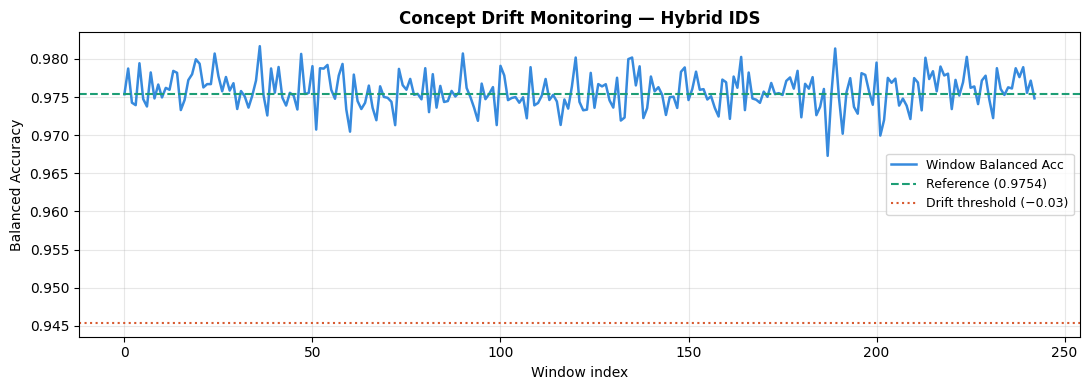

Saved → outputs/graphs/06_drift_summary.png


In [25]:
# Cell 13 — Concept drift monitoring summary (from notebook 05)

drift_detected = hybrid_data.get("drift_detected", [])
window_scores  = hybrid_data.get("window_scores", [])

if window_scores:
    print("CONCEPT DRIFT REPORT (Hybrid IDS)")
    print("=" * 50)
    print(f"  Total windows  : {len(window_scores)}")
    print(f"  Drift events   : {sum(drift_detected)}")
    print(f"  Min BAcc       : {min(window_scores):.4f}")
    print(f"  Max BAcc       : {max(window_scores):.4f}")
    print(f"  Mean BAcc      : {np.mean(window_scores):.4f}")
    print(f"  Std BAcc       : {np.std(window_scores):.4f}")
    if sum(drift_detected) == 0:
        print("  Status         : STABLE — no concept drift detected")
    else:
        print("  Status         : DRIFT DETECTED — retraining recommended")

    # Plot
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(window_scores, color="#378ADD",
            linewidth=1.8, label="Window Balanced Acc")
    ref = window_scores[0]
    ax.axhline(ref, color="#1D9E75", linestyle="--",
               linewidth=1.5, label=f"Reference ({ref:.4f})")
    ax.axhline(ref - 0.03, color="#D85A30", linestyle=":",
               linewidth=1.5, label="Drift threshold (−0.03)")
    for i, drift in enumerate(drift_detected):
        if drift:
            ax.axvline(i, color="red", alpha=0.4, linewidth=1)
    ax.set_xlabel("Window index")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title("Concept Drift Monitoring — Hybrid IDS",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("outputs/graphs/06_drift_summary.png", dpi=150)
    plt.show()
    print("Saved → outputs/graphs/06_drift_summary.png")
else:
    print("No drift data found in hybrid_data")

In [26]:
# Cell 14 — CDC / project compliance checklist

checklist = [
    # (description, satisfied)
    ("CICIDS2018 dataset (10 CSV files)",                    True),
    ("Binary labelling (Benign=0 / Attack=1)",               True),
    ("PowerTransformer + StandardScaler (no leakage)",       True),
    ("70/15/15 stratified train/val/test split",             True),
    ("Decision Tree",                                        True),
    ("Random Forest",                                        True),
    ("KNN",                                                  True),
    ("Naive Bayes",                                          True),
    ("SVM",                                                  True),
    ("XGBoost",                                              True),
    ("LightGBM",                                             True),
    ("Bayesian HPO — Optuna",                                True),
    ("Feature selection — XGBoost Feature Importance",      True),
    ("Feature selection — Univariate SelectKBest",          True),
    ("Feature selection — PCA (95% variance)",              True),
    ("Feature selection — PSO (evolutionary)",              True),
    ("Resampling — SMOTE",                                   True),
    ("Resampling — scale_pos_weight",                       True),
    ("Deep Learning — ResNetMLP + FocalLoss",               True),
    ("Hybrid ensemble (ML + DL fusion)",                    True),
    ("Signature + Anomaly (IsolationForest) fusion",        True),
    ("Concept drift detection (sliding window BAcc)",       True),
    ("Threshold tuning on validation set",                  True),
    ("IDS metrics: BAcc, MCC, FAR, FNR, F1, Recall",      True),
    ("ROC-AUC + PR-AUC reported",                           True),
    ("CNN / LSTM / Autoencoder / Transformer",              False),
]

done  = sum(1 for _, s in checklist if s)
total = len(checklist)

print("CDC COMPLIANCE CHECKLIST")
print("=" * 60)
for desc, done_flag in checklist:
    status = "✔  DONE" if done_flag else "✘  TODO"
    print(f"  [{status}]  {desc}")
print()
print(f"  Completed: {done}/{total} items")

CDC COMPLIANCE CHECKLIST
  [✔  DONE]  CICIDS2018 dataset (10 CSV files)
  [✔  DONE]  Binary labelling (Benign=0 / Attack=1)
  [✔  DONE]  PowerTransformer + StandardScaler (no leakage)
  [✔  DONE]  70/15/15 stratified train/val/test split
  [✔  DONE]  Decision Tree
  [✔  DONE]  Random Forest
  [✔  DONE]  KNN
  [✔  DONE]  Naive Bayes
  [✔  DONE]  SVM
  [✔  DONE]  XGBoost
  [✔  DONE]  LightGBM
  [✔  DONE]  Bayesian HPO — Optuna
  [✔  DONE]  Feature selection — XGBoost Feature Importance
  [✔  DONE]  Feature selection — Univariate SelectKBest
  [✔  DONE]  Feature selection — PCA (95% variance)
  [✔  DONE]  Feature selection — PSO (evolutionary)
  [✔  DONE]  Resampling — SMOTE
  [✔  DONE]  Resampling — scale_pos_weight
  [✔  DONE]  Deep Learning — ResNetMLP + FocalLoss
  [✔  DONE]  Hybrid ensemble (ML + DL fusion)
  [✔  DONE]  Signature + Anomaly (IsolationForest) fusion
  [✔  DONE]  Concept drift detection (sliding window BAcc)
  [✔  DONE]  Threshold tuning on validation set
  [✔  DONE]  I

In [27]:
# Cell 15 — Export complete results CSV for paper / report

EXPORT_COLS = [
    "Balanced Acc", "F1 Macro", "MCC",
    "Attack Recall", "Benign Recall",
    "Attack Precision", "Benign Precision",
    "FAR", "FNR", "ROC-AUC", "PR-AUC", "Train Time (s)"
]

export_rows = []
for name, m in final.items():
    row = {"Method": name}
    for c in EXPORT_COLS:
        val = m.get(c, "N/A")
        row[c] = round(val, 6) if isinstance(val, float) else val
    export_rows.append(row)

export_df = pd.DataFrame(export_rows)
export_df = export_df.sort_values(
    "Balanced Acc", ascending=False
).reset_index(drop=True)

export_df.to_csv("outputs/reports/06_final_comparison.csv", index=False)
print("Exported → outputs/reports/06_final_comparison.csv")
print(f"Rows: {len(export_df)}, Cols: {len(export_df.columns)}")
print()
print("Notebook 06 complete — evaluation finished.")
print(f"Outputs saved to outputs/graphs/ and outputs/reports/")

Exported → outputs/reports/06_final_comparison.csv
Rows: 16, Cols: 13

Notebook 06 complete — evaluation finished.
Outputs saved to outputs/graphs/ and outputs/reports/
